# 01 — Exploratory Data Analysis
InfraredSolarModules: 20,000 IR images (40x24), 12 classes.

This notebook establishes the data facts Phase 1 depends on:
1. Class distribution (the 49:1 No-Anomaly:Soiling imbalance).
2. What each fault *looks like* (per-class montages).
3. The **irradiance confound** — mean panel intensity varies widely *within* a class, which is the entire motivation for the residual-normalization approach.
4. Resize sanity: 40x24 -> 128x128 must use bicubic, not nearest (Pitfall 3).


In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.dataset import InfraredSolarDataset as D

DATA = ROOT / 'data'
meta = pd.read_json(DATA / 'module_metadata.json', orient='index')
meta.index.name = 'image_id'; meta = meta.reset_index().rename(columns={'image_filepath':'filepath'})
meta['class_idx'] = meta['anomaly_class'].map(D.CLASS_TO_IDX)
ORDER = list(D.CLASS_TO_IDX)  # canonical class order
print(len(meta), 'images'); meta.head()

20000 images


,image_id,filepath,anomaly_class,class_idx
0,13357,images/13357.jpg,No-Anomaly,0
1,13356,images/13356.jpg,No-Anomaly,0
2,19719,images/19719.jpg,No-Anomaly,0
3,11542,images/11542.jpg,No-Anomaly,0
4,11543,images/11543.jpg,No-Anomaly,0


## 1. Class distribution

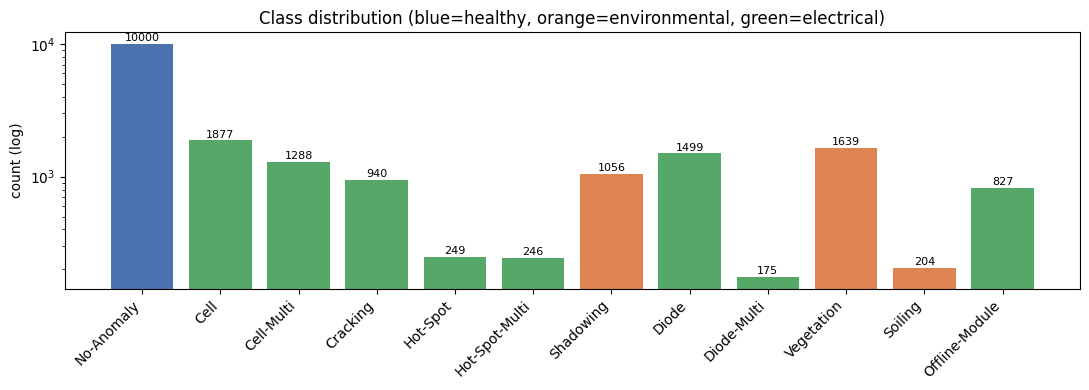

Imbalance ratio No-Anomaly : Soiling = 49.0 : 1


In [2]:
counts = meta['anomaly_class'].value_counts().reindex(ORDER)
fig, ax = plt.subplots(figsize=(11,4))
colors = ['#4C72B0' if c=='No-Anomaly' else ('#DD8452' if c in D.ENVIRONMENTAL else '#55A868') for c in ORDER]
ax.bar(ORDER, counts.values, color=colors, log=True)
ax.set_ylabel('count (log)'); ax.set_title('Class distribution (blue=healthy, orange=environmental, green=electrical)')
plt.xticks(rotation=45, ha='right')
for i,v in enumerate(counts.values): ax.text(i, v*1.05, str(v), ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print('Imbalance ratio No-Anomaly : Soiling =', round(counts['No-Anomaly']/counts['Soiling'],1), ': 1')

## 2. Per-class montage
Four random samples per class (raw 40x24, viridis).

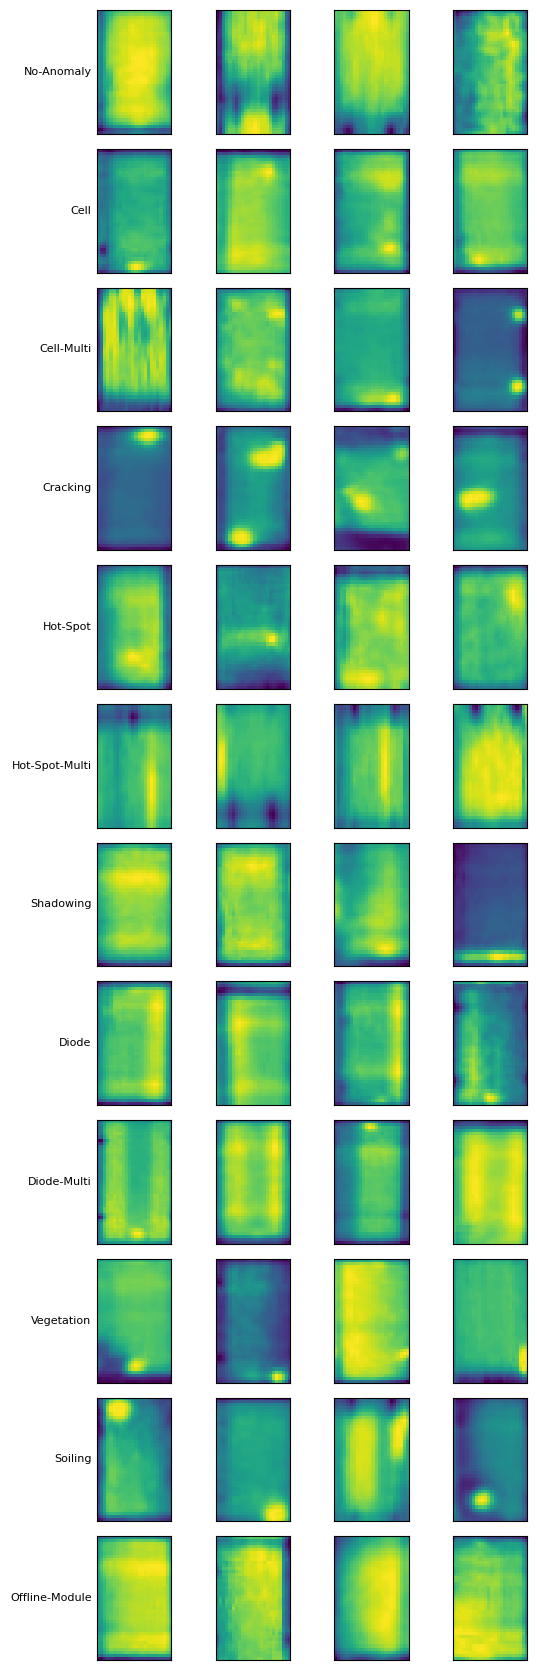

In [3]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(len(ORDER), 4, figsize=(6, 1.4*len(ORDER)))
for r, cls in enumerate(ORDER):
    ids = meta.loc[meta['anomaly_class']==cls, 'filepath'].sample(4, random_state=r).tolist()
    for c, fp in enumerate(ids):
        ax = axes[r, c]
        ax.imshow(np.asarray(Image.open(DATA/fp).convert('L')), cmap='viridis')
        ax.set_xticks([]); ax.set_yticks([])
        if c == 0: ax.set_ylabel(cls, fontsize=8, rotation=0, ha='right', va='center')
plt.tight_layout(); plt.show()

## 3. The irradiance confound
For each class, the distribution of **mean image intensity** (a proxy for absorbed irradiance + ambient). If a single fault class spans a wide intensity range, its raw thermal signature is entangled with the operating condition — exactly what the Stage-1 estimator + ΔT residual is designed to remove.

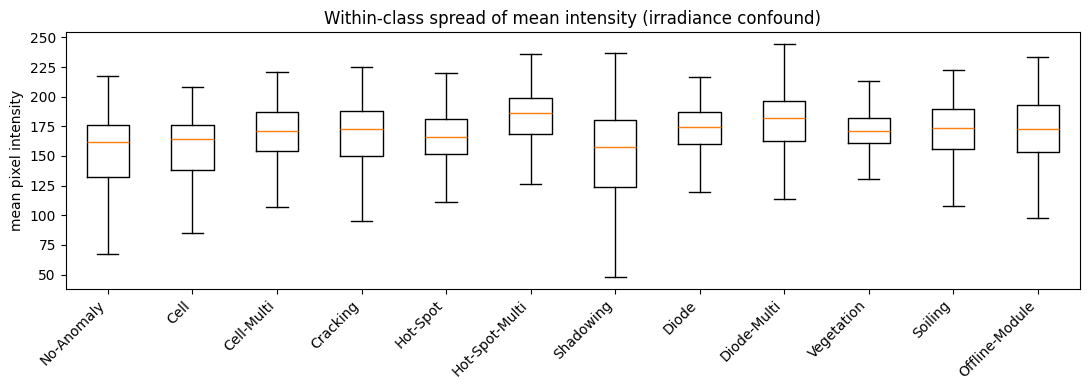

No-Anomaly mean intensity spans 63-217 (std 32.8) despite all being healthy -> this variation is the irradiance signal the estimator learns.


In [4]:
def mean_intensity(fp):
    return float(np.asarray(Image.open(DATA/fp).convert('L'), dtype=np.float32).mean())
samp = pd.concat([g.sample(min(len(g),250), random_state=1)
                  for _, g in meta.groupby('anomaly_class')]).copy()
samp['mean_int'] = samp['filepath'].map(mean_intensity)
fig, ax = plt.subplots(figsize=(11,4))
data = [samp.loc[samp['anomaly_class']==c, 'mean_int'].values for c in ORDER]
ax.boxplot(data, tick_labels=ORDER, showfliers=False)
ax.set_ylabel('mean pixel intensity'); ax.set_title('Within-class spread of mean intensity (irradiance confound)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
na = samp.loc[samp['anomaly_class']=='No-Anomaly','mean_int']
print(f'No-Anomaly mean intensity spans {na.min():.0f}-{na.max():.0f} (std {na.std():.1f}) despite all being healthy -> this variation is the irradiance signal the estimator learns.')

## 4. Resize sanity check (Pitfall 3)
40x24 -> 128x128. Nearest blocks; bicubic preserves gradients.

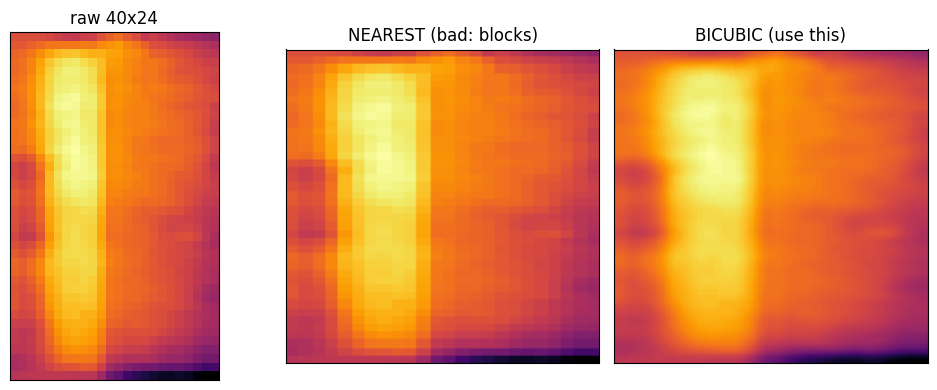

In [5]:
fp = meta.loc[meta['anomaly_class']=='Diode','filepath'].iloc[0]
raw = Image.open(DATA/fp).convert('L')
fig, ax = plt.subplots(1,3, figsize=(10,4))
ax[0].imshow(np.asarray(raw), cmap='inferno'); ax[0].set_title('raw 40x24')
ax[1].imshow(np.asarray(raw.resize((128,128), Image.NEAREST)), cmap='inferno'); ax[1].set_title('NEAREST (bad: blocks)')
ax[2].imshow(np.asarray(raw.resize((128,128), Image.BICUBIC)), cmap='inferno'); ax[2].set_title('BICUBIC (use this)')
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 5. Split integrity
Confirm the committed CSVs are leak-free and stratified as expected.

In [6]:
S = DATA / 'splits'
fault = {s: pd.read_csv(S/f'fault_{s}.csv') for s in ('train','val','test')}
na = {s: pd.read_csv(S/f'noanomaly_{s}.csv') for s in ('train','val','test')}
all_ids = pd.concat([d for d in {**{f'f_{k}':v for k,v in fault.items()}, **{f'n_{k}':v for k,v in na.items()}}.values()])['image_id']
assert all_ids.is_unique and len(all_ids)==20000, 'split leak!'
print('20k images, no leaks across 6 split files.')
pd.DataFrame({s: fault[s]['anomaly_class'].value_counts() for s in ('train','val','test')}).reindex([c for c in ORDER if c!='No-Anomaly'])

20k images, no leaks across 6 split files.


,train,val,test
anomaly_class,,,
Cell,1313,282,282
Cell-Multi,902,193,193
Cracking,658,141,141
Hot-Spot,175,37,37
Hot-Spot-Multi,172,37,37
Shadowing,740,158,158
Diode,1049,225,225
Diode-Multi,123,26,26
Vegetation,1147,246,246


## Takeaways
- **49:1** imbalance (No-Anomaly:Soiling) -> focal + inverse-freq weighting are mandatory, macro-F1 is the only honest headline metric.
- Mean intensity varies widely *within* every class, including the healthy class -> raw pixels conflate fault with irradiance. This is the gap the ΔT residual closes.
- Use **bicubic** for the 128x128 upscale.
- Splits are committed, deterministic, and leak-free; estimator will train on `noanomaly_train` only.
